In [25]:
#we are going to join Participating Restaurants ['name'] to MOP ['Restaurants'] to get the address values
#using lat/lon and plotly

# map_participating_restaurants.py
# Create a Plotly animated map of participating restaurants by Year

# participating_restaurants_mapbox_by_year.py
import pandas as pd
import plotly.express as px
import math

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html"

df = pd.read_csv(CSV)

# ---- Columns & types ----
if not {"Lat","Lon"}.issubset(df.columns):
    raise ValueError("CSV must contain 'Lat' and 'Lon' columns.")
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Find the Shell Only Weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if weight_col is None:
    raise ValueError("Couldn't find a 'Shell Only Weight' column.")

# Ensure Year exists and treat it as categorical (string) so colors/legend are discrete & stable
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = (pd.to_datetime(df[date_like], errors="coerce").dt.year
                  if date_like else "All Years")
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Keep valid rows and apply filter: only keep rows where Shell Only Weight > 0
data = df.dropna(subset=["Lat","Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce")
data = data[(data[weight_col] > 0) & data["Year"].notna()].copy()

# Year order for consistent colors/slider order
year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# Per-year N (for hover)
name_col = "Restaurant" if "Restaurant" in data.columns else ("name" if "name" in data.columns else None)
year_counts = (
    data.groupby("Year")[name_col if name_col else "Year"]
        .nunique()
        .reset_index(name="N (restaurants this year)")
)
n_map = dict(zip(year_counts["Year"], year_counts["N (restaurants this year)"]))
data["N (restaurants this year)"] = data["Year"].map(n_map)

# Auto-center and zoom from extent
if len(data):
    minlat, maxlat = float(data["Lat"].min()), float(data["Lat"].max())
    minlon, maxlon = float(data["Lon"].min()), float(data["Lon"].max())
    center = {"lat": (minlat + maxlat) / 2, "lon": (minlon + maxlon) / 2}
    span = max(maxlat - minlat, maxlon - minlon)
    zoom = max(5, min(12, 8.5 - math.log(max(span, 0.0001), 2)))
else:
    center, zoom = {"lat": 41.72, "lon": -70.20}, 8.0

# Hover fields
hover_cols = []
if name_col: hover_cols.append(name_col)
if "Full Address" in data.columns: hover_cols.append("Full Address")
hover_cols += ["Year", weight_col, "N (restaurants this year)"]

# Build figure — color by Year (discrete), legend ON
fig = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat", lon="Lon",
    color="Year",
    category_orders={"Year": year_order},
    animation_frame="Year",
    hover_name=None,
    hover_data=hover_cols,
    # You can pick a palette; this one is readable:
    color_discrete_sequence=px.colors.qualitative.Set2,
    zoom=zoom, height=760
)

fig.update_traces(marker=dict(size=10, opacity=0.9))

fig.update_layout(
    title="Participating Restaurants by Year (Shell Only Weight > 0)",
    map_style="open-street-map",
    map=dict(center=center, zoom=zoom),
    showlegend=True,                 # <— legend ON
    legend_title_text="Year",
    margin=dict(l=10, r=10, t=55, b=10),
)

# Slow the animation
frame_ms, trans_ms = 1600, 400
if fig.layout.updatemenus:
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = frame_ms
    fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = trans_ms
    if len(fig.layout.updatemenus[0].buttons) > 1:
        fig.layout.updatemenus[0].buttons[1].args[1]["frame"]["duration"] = frame_ms
        fig.layout.updatemenus[0].buttons[1].args[1]["transition"]["duration"] = trans_ms
if fig.layout.sliders:
    fig.layout.sliders[0]["transition"]["duration"] = trans_ms

fig.write_html(
    OUT,
    include_plotlyjs="cdn",
    full_html=True,
    config={"scrollZoom": True, "displaylogo": False}
)
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html


In [22]:
# fix_lat_lon.py
import pandas as pd
from pathlib import Path

# Path to your merged file
IN_PATH  = Path(r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_exact_v4.csv")
OUT_PATH = Path(r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv")

# Load
df = pd.read_csv(IN_PATH)

# Ensure numeric
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Define condition for swapped coordinates
# (lat should be positive and lon negative in Massachusetts)
swap_mask = (df["Lat"] < 0) | (df["Lon"] > 0)

# Perform swap safely
df.loc[swap_mask, ["Lat", "Lon"]] = df.loc[swap_mask, ["Lon", "Lat"]].values

# Optional sanity check: enforce correct sign (positive lat, negative lon)
df["Lat"] = df["Lat"].abs()
df["Lon"] = -df["Lon"].abs()

# Save cleaned CSV
df.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned file to {OUT_PATH}")
print(f"Total swapped rows: {swap_mask.sum()}")

Saved cleaned file to C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv
Total swapped rows: 118



Number of participating restaurants with nonzero Shell Only Weight:

 Year  Unique Restaurants (with shells)
 2021                                 8
 2022                                17
 2023                                20
 2024                                25
 2025                                23


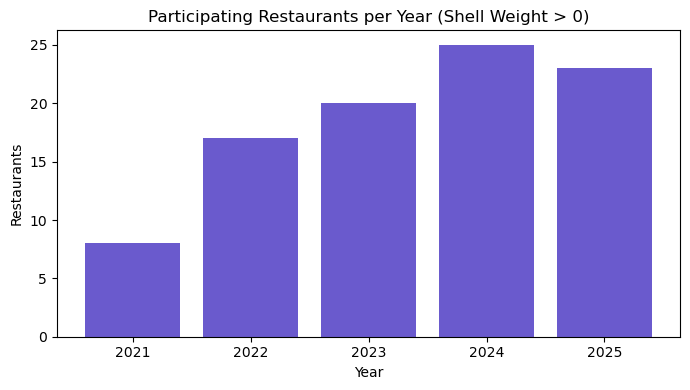

In [30]:
# restaurants_per_year_filtered.py
import pandas as pd
import matplotlib.pyplot as plt

# path to your cleaned merged file
FILE = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"

# Load data
df = pd.read_csv(FILE)

# ---- identify key columns ----
rest_col = "Restaurant" if "Restaurant" in df.columns else "name"
weight_col = next((c for c in df.columns if "Shell" in c and "Weight" in c), None)
if weight_col is None:
    raise ValueError("Couldn't find 'Shell Only Weight' column.")

# Ensure Year column exists
if "Year" not in df.columns:
    # Try inferring from date-like column
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    if date_like:
        df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year
    else:
        raise ValueError("No 'Year' column found in the dataset.")

# Convert weights to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")

# ---- filter out zero or missing weights ----
df_valid = df[df[weight_col] > 0].copy()

# ---- count unique restaurants per year ----
summary = (
    df_valid.groupby("Year")[rest_col]
            .nunique()
            .reset_index(name="Unique Restaurants (with shells)")
            .sort_values("Year")
)

print("\nNumber of participating restaurants with nonzero Shell Only Weight:\n")
print(summary.to_string(index=False))

# ---- optional bar chart ----
plt.figure(figsize=(7,4))
plt.bar(summary["Year"].astype(str), summary["Unique Restaurants (with shells)"], color="#6A5ACD")
plt.title("Participating Restaurants per Year (Shell Weight > 0)")
plt.xlabel("Year")
plt.ylabel("Restaurants")
plt.tight_layout()
plt.show()

In [100]:
# participating_restaurants_map_by_year.py
import pandas as pd
import plotly.express as px
import numpy as np
import math
import copy

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize lat/lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("CSV must have latitude/longitude columns named like Lat/Latitude and Lon/Lng/Longitude.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column (flexible match)
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if weight_col is None:
    raise ValueError("Couldn't find a 'Shell Only Weight' column.")

# Year column (derive if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = (pd.to_datetime(df[date_like], errors="coerce").dt.year
                  if date_like else "All Years")
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# ------------ Filter valid rows ------------
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce")
data = data[(data[weight_col] > 0) & data["Year"].notna()].copy()
if data.empty:
    raise ValueError("No rows remain after filtering for valid coordinates and positive shell weight.")

# ------------ Tight Cape Cod window ------------
# Very narrow bounds so only the Cape stays in frame (Provincetown hook through Chatham/Hyannis)
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    (data["Lat"] >= CAPE_BOUNDS["lat_min"]) & (data["Lat"] <= CAPE_BOUNDS["lat_max"]) &
    (data["Lon"] >= CAPE_BOUNDS["lon_min"]) & (data["Lon"] <= CAPE_BOUNDS["lon_max"])
].copy()
if data.empty:
    raise ValueError("After restricting to tight Cape bounds, no rows remain. Loosen CAPE_BOUNDS slightly if needed.")

# Hover display columns (safe fallbacks if missing)
name_col = "Restaurant" if "Restaurant" in data.columns else ("name" if "name" in data.columns else None)
addr_col = "Full Address" if "Full Address" in data.columns else None
if name_col is None:
    data["Restaurant (missing)"] = "N/A"; name_col = "Restaurant (missing)"
if addr_col is None:
    data["Full Address (missing)"] = "N/A"; addr_col = "Full Address (missing)"

# Year order for stable colors/slider
year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Cape-centered view (tight frame) ------------
center = {"lat": 41.86, "lon": -70.05}  # center between the hook and mid-Cape
zoom   = 8.6                            # tighter view so the Cape fills the frame

# ------------ Jitter to separate overlaps ------------
R_METERS = 60.0  # ~60 m radius

def meters_to_deg(lat):
    lat_deg = R_METERS / 111_320.0
    lon_deg = R_METERS / (111_320.0 * max(0.25, math.cos(math.radians(lat))))
    return lat_deg, lon_deg

def jitter_group(sub):
    if len(sub) == 1:
        sub = sub.copy()
        sub["Lat_j"] = sub["Lat"]; sub["Lon_j"] = sub["Lon"]
        return sub
    lat0 = float(sub["Lat"].iloc[0]); lon0 = float(sub["Lon"].iloc[0])
    dlat, dlon = meters_to_deg(lat0)
    k = len(sub)
    phase = np.random.uniform(0, 2*np.pi)
    angles = phase + np.linspace(0, 2*np.pi, k, endpoint=False)
    r = 1.0 + 0.08 * min(10, k)
    sub = sub.copy()
    sub["Lat_j"] = lat0 + r * dlat * np.sin(angles)
    sub["Lon_j"] = lon0 + r * dlon * np.cos(angles)
    return sub

data = (
    data.groupby(["Year", "Lat", "Lon"], as_index=False, group_keys=False)
        .apply(jitter_group, include_groups=True)
        .reset_index(drop=True)
)

# ------------ Satellite basemap (Esri World Imagery) ------------
satellite_style = {
    "version": 8,
    "sources": {
        "esri": {
            "type": "raster",
            "tiles": [
                "https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ],
            "tileSize": 256,
            "attribution": "Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        }
    },
    "layers": [{"id": "esri", "type": "raster", "source": "esri"}],
}

# ------------ Build COLORED figure (strict hover) ------------
custom_cols = [name_col, addr_col, weight_col]

colored = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    category_orders={"Year": year_order},
    animation_frame="Year",
    hover_name=None,
    hover_data={},                 # nothing auto-added
    custom_data=custom_cols,       # ONLY these go into hovertemplate
    color_discrete_sequence=px.colors.qualitative.Set2,
    zoom=zoom, height=760
)

hover_tmpl = (
    "<b>" + name_col + "</b>: %{customdata[0]}<br>"
    "<b>" + addr_col + "</b>: %{customdata[1]}<br>"
    "<b>" + weight_col + "</b>: %{customdata[2]:,.0f}"
    "<extra></extra>"
)

colored.update_traces(
    marker_size=16,
    marker_opacity=0.98,
    marker_symbol="circle",
    hovertemplate=hover_tmpl,
    hoverinfo="text"
)

colored.update_layout(
    title="Participating Restaurants",
    map_style=satellite_style,
    map=dict(center=center, zoom=zoom),
    showlegend=True,
    legend_title_text="Year",
    margin=dict(l=10, r=10, t=60, b=10),
    hoverlabel=dict(align="left"),
)

# ------------ Build HALO figure (white outline, no hover) ------------
halo = copy.deepcopy(colored)
for tr in halo.data:
    tr.update(marker=dict(size=20, opacity=0.35, color="white"),
              showlegend=False, hovertemplate="<extra></extra>", hoverinfo="skip")
for fr in (halo.frames or []):
    for tr in fr.data:
        tr.update(marker=dict(size=20, opacity=0.35, color="white"),
                  showlegend=False, hovertemplate="<extra></extra>", hoverinfo="skip")

# ------------ Compose final figure (halo under colored) ------------
fig = halo
fig.add_traces(colored.data)  # append colored traces after halo

# Merge frames by name: halo first, then colored
halo_frames_by_name = {fr.name: fr for fr in (halo.frames or [])}
new_frames = []
for fr_col in (colored.frames or []):
    fr_halo = halo_frames_by_name.get(fr_col.name)
    if fr_halo:
        combined = type(fr_col)(name=fr_col.name,
                                data=tuple(list(fr_halo.data) + list(fr_col.data)),
                                traces=None)
        new_frames.append(combined)
    else:
        new_frames.append(fr_col)
fig.frames = tuple(new_frames)

# --- Enforce hover everywhere ---
for tr in fig.data:
    if getattr(tr.marker, "color", None) == "white":
        tr.update(hoverinfo="skip", hovertemplate="<extra></extra>")
    else:
        tr.update(hoverinfo="text", hovertemplate=hover_tmpl)
for fr in (fig.frames or []):
    for tr in fr.data:
        if getattr(tr.marker, "color", None) == "white":
            tr.update(hoverinfo="skip", hovertemplate="<extra></extra>")
        else:
            tr.update(hoverinfo="text", hovertemplate=hover_tmpl)

# ------------ Slow animation (very slow) ------------
frame_ms, trans_ms = 12000, 1500  # ~12s per year, long cross-fade
if fig.layout.updatemenus:
    for b in fig.layout.updatemenus[0].buttons:
        b.args[1]["frame"]["duration"] = frame_ms
        b.args[1]["transition"]["duration"] = trans_ms
if fig.layout.sliders:
    fig.layout.sliders[0]["transition"]["duration"] = trans_ms

# ------------ Save ------------
fig.write_html(
    OUT,
    include_plotlyjs="cdn",
    full_html=True,
    config={"scrollZoom": True, "displaylogo": False}
)
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html


C:\Users\suzan\AppData\Local\Temp\ipykernel_4100\1557725203.py:95: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [1]:
#v3
# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, math, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"]=pd.to_numeric(df["Lat"],errors="coerce")
df["Lon"]=pd.to_numeric(df["Lon"],errors="coerce")

# Shell weight column
weight_col=next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()),None)
if not weight_col: raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like=next((c for c in df.columns if "date" in c.lower()),None)
    df["Year"]=pd.to_datetime(df[date_like],errors="coerce").dt.year if date_like else "All Years"
df["Year"]=df["Year"].astype("Int64").astype(str).replace("<NA>","All Years")

# Clean + filter
data=df.dropna(subset=["Lat","Lon"]).copy()
data[weight_col]=pd.to_numeric(data[weight_col],errors="coerce").fillna(0)
data=data[data[weight_col]>=0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS={"lat_min":41.62,"lat_max":42.08,"lon_min":-70.70,"lon_max":-69.88}
data=data[(data["Lat"].between(CAPE_BOUNDS["lat_min"],CAPE_BOUNDS["lat_max"]))&
          (data["Lon"].between(CAPE_BOUNDS["lon_min"],CAPE_BOUNDS["lon_max"]))]

# Required cols
name_col="Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns: data[name_col]="Unknown"
addr_col=("Full Address" if "Full Address" in data.columns
          else ("Address" if "Address" in data.columns else None))
if addr_col is None:
    addr_col="__addr__"; data[addr_col]="N/A"

year_order=sorted(data["Year"].unique(), key=lambda x: (x!="All Years", x))

# ---- Jitter overlapping points (silence groupby.apply deprecation) ---
R_METERS=60
def meters_to_deg(lat):
    lat_deg=R_METERS/111_320
    lon_deg=R_METERS/(111_320*max(0.25,math.cos(math.radians(lat))))
    return lat_deg,lon_deg

def jitter_group(sub):
    sub=sub.copy()
    if len(sub)<=1:
        sub["Lat_j"]=sub["Lat"]; sub["Lon_j"]=sub["Lon"]; return sub
    lat0,lon0=sub["Lat"].iloc[0],sub["Lon"].iloc[0]
    dlat,dlon=meters_to_deg(lat0)
    k=len(sub); phase=np.random.uniform(0,2*np.pi); ang=phase+np.linspace(0,2*np.pi,k,endpoint=False)
    sub["Lat_j"]=lat0+dlat*np.sin(ang); sub["Lon_j"]=lon0+dlon*np.cos(ang)
    return sub

# ✅ keep Lat/Lon inside sub
data = (data.groupby(["Year","Lat","Lon"], as_index=False, group_keys=False)
           .apply(jitter_group, include_groups=True)
           .reset_index(drop=True))

# Brand colors
brand_colors=["#3DB0C3","#99D6CE","#2E8F97","#ECE6DE","#0E013D"]

# ------------ MAP FIGURE (no mapbox deprecation) ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map=px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    animation_frame="Year",
    category_orders={"Year":year_order},
    color_discrete_sequence=brand_colors,
    hover_name=name_col,
    hover_data={},                   # we control hover via template
    custom_data=custom_cols,
    map_style="carto-positron",      # token-free styles: 'open-street-map', 'carto-positron', 'carto-darkmatter'
    center={"lat":41.86,"lon":-70.05},
    zoom=8.6, height=640
)

hover_template=(
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)
fig_map.update_layout(
    title="Participating Restaurants",
    legend=dict(
        orientation="h",yanchor="top",y=0.99,xanchor="center",x=0.5,
        bgcolor="rgba(255,255,255,0.8)",bordercolor="rgba(0,0,0,0.2)",borderwidth=1
    ),
    margin=dict(l=0,r=20,t=60,b=0)
)

# Moderate animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args)>=2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"]=800
            b.args[1]["transition"]["duration"]=400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"]=400

# ------------ BAR DATA ------------
bar_long=(data.groupby(["Year",name_col],as_index=False)[weight_col].sum()
            .rename(columns={weight_col:"Weight"}))
bar_years=sorted(bar_long["Year"].unique(), key=lambda x: (x!="All Years", x))
restaurants=sorted(bar_long[name_col].unique())

palette=(px.colors.qualitative.Safe+px.colors.qualitative.Set2+
         px.colors.qualitative.Set3+px.colors.qualitative.Plotly)
color_map={r:palette[i%len(palette)] for i,r in enumerate(restaurants)}

# Serialize for JS
data_json=json.dumps(bar_long.to_dict(orient="records"))
years_json=json.dumps(bar_years)
colors_json=json.dumps(color_map)

map_html=pio.to_html(fig_map,include_plotlyjs="cdn",full_html=False,config={"displaylogo":False},div_id="mapFig")
bar_placeholder='<div id="barFig"></div>'

# ------------ JS Sync Script ------------
js=f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year)).sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar', x:[year], y:[r.Weight||0], name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total], mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub = document.getElementById('barSubtitle');
    if (sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
}})();
</script>
"""

# ------------ HTML Layout ------------
html=f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">{map_html}</div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html,encoding="utf-8")
print(f"Saved: {OUT}")

C:\Users\suzan\AppData\Local\Temp\ipykernel_16184\1973237707.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(jitter_group, include_groups=True)


Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [3]:
#v4: fix what attributes show when hovering


# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, math, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean + filter
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce").fillna(0)
data = data[data[weight_col] >= 0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    data["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & data["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns:
    data[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in data.columns else ("Address" if "Address" in data.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    data[addr_col] = "N/A"

year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Jitter overlapping points (vectorized; no groupby.apply) ------------
R_METERS = 60
# group id, size, and index within group
g = data.groupby(["Year", "Lat", "Lon"], sort=False)
data["_gid"] = g.ngroup()
data["_n"] = g["Lat"].transform("size")
data["_i"] = g.cumcount()

# one random phase per group
n_groups = int(data["_gid"].max()) + 1
phases = np.random.uniform(0, 2*np.pi, size=n_groups)
data["_phase"] = data["_gid"].map(dict(enumerate(phases)))

# per-row angle and meter->degree scales
data["_ang"] = data["_phase"] + 2*np.pi * (data["_i"] / data["_n"].clip(lower=1))
data["_dlat"] = R_METERS / 111_320.0
data["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(data["Lat"]))))

# apply jitter only when group size > 1
mask = data["_n"] > 1
data["Lat_j"] = data["Lat"]
data["Lon_j"] = data["Lon"]
data.loc[mask, "Lat_j"] = data.loc[mask, "Lat"] + data.loc[mask, "_dlat"] * np.sin(data.loc[mask, "_ang"])
data.loc[mask, "Lon_j"] = data.loc[mask, "Lon"] + data.loc[mask, "_dlon"] * np.cos(data.loc[mask, "_ang"])

# cleanup temp cols
data.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"], inplace=True)

# Brand colors
brand_colors = ["#3DB0C3", "#99D6CE", "#2E8F97", "#ECE6DE", "#0E013D"]

# ------------ MAP (Plotly token-free) ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    animation_frame="Year",
    category_orders={"Year": year_order},
    color_discrete_sequence=brand_colors,
    hover_name=name_col,
    hover_data={},                 # we control hover via template
    custom_data=custom_cols,
    map_style="carto-positron",    # also: 'open-street-map', 'carto-darkmatter'
    center={"lat": 41.86, "lon": -70.05},
    zoom=8.6, height=640
)

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)
fig_map.update_layout(
    title="Participating Restaurants",
    legend=dict(
        orientation="h", yanchor="top", y=0.99, xanchor="center", x=0.5,
        bgcolor="rgba(255,255,255,0.8)", bordercolor="rgba(0,0,0,0.2)", borderwidth=1
    ),
    margin=dict(l=0, r=20, t=60, b=0)
)

# Animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args) >= 2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"] = 800
            b.args[1]["transition"]["duration"] = 400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"] = 400

# ------------ BAR DATA ------------
bar_long = (data.groupby(["Year", name_col], as_index=False)[weight_col].sum()
              .rename(columns={weight_col: "Weight"}))
bar_years = sorted(bar_long["Year"].unique(), key=lambda x: (x != "All Years", x))
restaurants = sorted(bar_long[name_col].unique())

palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
color_map = {r: palette[i % len(palette)] for i, r in enumerate(restaurants)}

# Serialize for JS
data_json = json.dumps(bar_long.to_dict(orient="records"))
years_json = json.dumps(bar_years)
colors_json = json.dumps(color_map)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS Sync Script (hover fix uses fullData.name) ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">{map_html}</div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [7]:
#V5: color by restaurant

# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean + filter
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce").fillna(0)
data = data[data[weight_col] >= 0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    data["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & data["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns:
    data[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in data.columns else ("Address" if "Address" in data.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    data[addr_col] = "N/A"

year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Restaurant color palette (shared) ------------
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
restaurants_all = sorted(data[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(restaurants_all)}

# ------------ Jitter overlapping points (vectorized) ------------
R_METERS = 60
g = data.groupby(["Year", "Lat", "Lon"], sort=False)
data["_gid"] = g.ngroup()
data["_n"] = g["Lat"].transform("size")
data["_i"] = g.cumcount()
n_groups = int(data["_gid"].max()) + 1
phases = np.random.uniform(0, 2*np.pi, size=n_groups)
data["_phase"] = data["_gid"].map(dict(enumerate(phases)))
data["_ang"] = data["_phase"] + 2*np.pi * (data["_i"] / data["_n"].clip(lower=1))
data["_dlat"] = R_METERS / 111_320.0
data["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(data["Lat"]))))
mask = data["_n"] > 1
data["Lat_j"] = data["Lat"]
data["Lon_j"] = data["Lon"]
data.loc[mask, "Lat_j"] = data.loc[mask, "Lat"] + data.loc[mask, "_dlat"] * np.sin(data.loc[mask, "_ang"])
data.loc[mask, "Lon_j"] = data.loc[mask, "Lon"] + data.loc[mask, "_dlon"] * np.cos(data.loc[mask, "_ang"])
data.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"], inplace=True)

# ------------ MAP ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color=name_col,                         # color by restaurant
    animation_frame="Year",
    category_orders={"Year": year_order},
    color_discrete_map=color_map,
    hover_name=name_col,
    hover_data={},
    custom_data=custom_cols,
    map_style="carto-positron",
    center={"lat": 41.86, "lon": -70.05},
    zoom=8.6, height=640
)
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)

# HIDE Plotly legend on the map (we'll render our own below the slider)
fig_map.update_layout(
    title="Participating Restaurants",
    showlegend=False,
    margin=dict(l=0, r=20, t=60, b=0)
)

# Animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args) >= 2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"] = 800
            b.args[1]["transition"]["duration"] = 400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"] = 400

# ------------ BAR DATA ------------
bar_long = (data.groupby(["Year", name_col], as_index=False)[weight_col].sum()
              .rename(columns={weight_col: "Weight"}))
bar_years = sorted(bar_long["Year"].unique(), key=lambda x: (x != "All Years", x))

# Serialize for JS
data_json = json.dumps(bar_long.to_dict(orient="records"))
years_json = json.dumps(bar_years)
colors_json = json.dumps(color_map)
names_json = json.dumps(restaurants_all)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS: bar sync + custom legend below slider ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAMES={names_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');
  const legendDiv=document.getElementById('legendBelow');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  // --- Custom legend below the slider ---
  function renderLegend(){{
    if(!legendDiv) return;
    let html = '';
    for(const r of NAMES){{
      const c = COLORS[r] || '#888';
      html += `<div class="legend-item"><span class="swatch" style="background:${{c}}"></span><span class="label">${{r}}</span></div>`;
    }}
    legendDiv.innerHTML = html;
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});

  renderBar(currentYear());
  renderLegend();
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
/* Custom legend styles */
#legendBelow{{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}}
#legendBelow .legend-item{{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}}
#legendBelow{{display:flex;flex-wrap:wrap;justify-content:flex-start}}
#legendBelow .swatch{{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}}
#legendBelow .label{{font-size:12px;color:#333}}
/* keep Plotly's own controls intact (slider remains inside the map figure) */
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    {map_html}
    <!-- Custom legend sits BELOW the map (and thus visually below the slider) -->
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [3]:
#V5 implement for loop filtering SOW = 0
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean base
df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in df.columns else "name"
if name_col not in df.columns: df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None: addr_col = "__addr__"; df[addr_col] = "N/A"

years = sorted(df["Year"].unique(), key=lambda x: (x != "All Years", x))

# Consistent colors for any restaurant that participates (>0 at least once)
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df.loc[df[weight_col] > 0, name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper: jitter per-year subset --------
def jitter_year(sub):
    if sub.empty:
        sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
        return sub
    R_METERS = 60
    g = sub.groupby(["Lat","Lon"], sort=False)
    sub = sub.copy()
    sub["_gid"] = g.ngroup()
    sub["_n"] = g["Lat"].transform("size")
    sub["_i"] = g.cumcount()
    phases = np.random.uniform(0, 2*np.pi, size=int(sub["_gid"].max())+1)
    sub["_phase"] = sub["_gid"].map(dict(enumerate(phases)))
    sub["_ang"] = sub["_phase"] + 2*np.pi * (sub["_i"] / sub["_n"].clip(lower=1))
    sub["_dlat"] = R_METERS / 111_320.0
    sub["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(sub["Lat"]))))
    mask = sub["_n"] > 1
    sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
    sub.loc[mask, "Lat_j"] = sub.loc[mask, "Lat"] + sub.loc[mask, "_dlat"] * np.sin(sub.loc[mask, "_ang"])
    sub.loc[mask, "Lon_j"] = sub.loc[mask, "Lon"] + sub.loc[mask, "_dlon"] * np.cos(sub.loc[mask, "_ang"])
    return sub.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"])

# -------- build frames (PER YEAR FILTER) --------
def make_px_for_year(y):
    sub = df[(df["Year"] == y) & (df[weight_col] > 0)].copy()
    if not sub.empty:
        sub = (sub.groupby([name_col], as_index=False)
                .agg({weight_col:"sum","Lat":"first","Lon":"first",addr_col:"first"}))
        sub = sub.rename(columns={weight_col:"YearWeight"})
        sub = jitter_year(sub)
    else:
        sub["YearWeight"] = pd.Series(dtype=float)
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j", lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j":False,"Lon_j":False,"Lat":False,"Lon":False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6, height=640
    )
    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )
    for tr in fig_y.data:
        tr.update(marker=dict(size=14), hovertemplate=hover_template, showlegend=False)
    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)

frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Controls strip directly under map (above attribution) ----
# Use a small positive y (0.04–0.06) so it sits *inside* the plotting area just above map attribution.
controls_y = 0.055

sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]

updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 800, "redraw": True},
                          "transition": {"duration": 400}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),  # small bottom; controls live inside plot at y≈0.055
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (stacked per year) ------------
bar_long = []
for y in years:
    sub = df[(df["Year"] == y) & (df[weight_col] > 0)]
    if not sub.empty:
        sums = (sub.groupby(name_col, as_index=False)[weight_col]
                  .sum().rename(columns={weight_col: "Weight"}))
        sums["Year"] = y
        bar_long.append(sums[["Year", name_col, "Weight"]])
bar_long = pd.concat(bar_long, ignore_index=True) if bar_long else pd.DataFrame(columns=["Year", name_col, "Weight"])

# Serialize data for JS / legend
data_json   = json.dumps(bar_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS: bar sync + legend ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAMES={names_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');
  const legendDiv=document.getElementById('legendBelow');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .filter(r=>(r.Weight||0)>0)
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  function renderLegend(){{
    if(!legendDiv) return;
    let html = '';
    for(const r of NAMES){{
      const c = COLORS[r] || '#888';
      html += `<div class="legend-item"><span class="swatch" style="background:${{c}}"></span><span class="label">${{r}}</span></div>`;
    }}
    legendDiv.innerHTML = html;
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
  renderLegend();
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
#legendBelow{{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}}
#legendBelow .legend-item{{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}}
#legendBelow{{display:flex;flex-wrap:wrap;justify-content:flex-start}}
#legendBelow .swatch{{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}}
#legendBelow .label{{font-size:12px;color:#333}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    {map_html}
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [13]:
# V8 — Button toggle (By Year / By Restaurant), dropdown populates only in Restaurant mode
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper (jitter overlapping points) --------
def jitter_year(sub):
    if sub.empty:
        sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
        return sub
    R_METERS = 60
    g = sub.groupby(["Lat","Lon"], sort=False)
    sub = sub.copy()
    sub["_gid"] = g.ngroup()
    sub["_n"] = g["Lat"].transform("size")
    sub["_i"] = g.cumcount()
    phases = np.random.uniform(0, 2*np.pi, size=int(sub["_gid"].max())+1)
    sub["_phase"] = sub["_gid"].map(dict(enumerate(phases)))
    sub["_ang"] = sub["_phase"] + 2*np.pi * (sub["_i"] / sub["_n"].clip(lower=1))
    sub["_dlat"] = R_METERS / 111_320.0
    sub["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(sub["Lat"]))))
    mask = sub["_n"] > 1
    sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
    sub.loc[mask, "Lat_j"] = sub.loc[mask, "Lat"] + sub.loc[mask, "_dlat"] * np.sin(sub.loc[mask, "_ang"])
    sub.loc[mask, "Lon_j"] = sub.loc[mask, "Lon"] + sub.loc[mask, "_dlon"] * np.cos(sub.loc[mask, "_ang"])
    return sub.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"])

# -------- Map frames by year --------
def make_px_for_year(y):
    sub = df_pos[df_pos["Year"] == y].copy()
    if not sub.empty:
        sub = (sub.groupby([name_col], as_index=False)
                 .agg({weight_col:"sum","Lat":"first","Lon":"first",addr_col:"first"}))
        sub = sub.rename(columns={weight_col:"YearWeight"})
        sub = sub[sub["YearWeight"] > 0]
        sub = jitter_year(sub)
    else:
        sub["YearWeight"] = pd.Series(dtype=float)
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j", lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j":False,"Lon_j":False,"Lat":False,"Lon":False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6, height=640
    )
    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )
    for tr in fig_y.data:
        tr.update(marker=dict(size=14), hovertemplate=hover_template, showlegend=False)
    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)
frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = []
for y in years:
    sub = df_pos[df_pos["Year"] == y]
    if not sub.empty:
        sums = (sub.groupby(name_col, as_index=False)[weight_col]
                  .sum().rename(columns={weight_col: "Weight"}))
        sums = sums[sums["Weight"] > 0]
        sums["Year"] = y
        bar_long.append(sums[["Year", name_col, "Weight"]])
bar_long = pd.concat(bar_long, ignore_index=True) if bar_long else pd.DataFrame(columns=["Year", name_col, "Weight"])

rest_year_long = []
for r in restaurant_all:
    sub = df_pos[df_pos[name_col] == r]
    if sub.empty:
        continue
    sums = (sub.groupby("Year", as_index=False)[weight_col]
              .sum().rename(columns={weight_col: "Weight"}))
    sums = sums[sums["Weight"] > 0]
    if not sums.empty:
        sums[name_col] = r
        rest_year_long.append(sums[["Year", name_col, "Weight"]])
rest_year_long = (pd.concat(rest_year_long, ignore_index=True)
                  if rest_year_long else pd.DataFrame(columns=["Year", name_col, "Weight"]))

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [18]:
#V9

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Experimental 12.3 build new table for non-zero by year 
# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()



    


# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.

    Methodology
    ----------
    For each year we get one row per restaurant, with a unique Lat/Lon.
    We only want to separate restaurants whose markers would fall on top of
    each other (or extremely close) at the map's zoom level.

    1. Work in *meters* instead of arbitrary degree buckets.
       - Approximate:
           dy (m) = (lat_i - lat_ref)  * 111_320
           dx (m) = (lon_i - lon_ref)  * 111_320 * cos(lat_mean)
    2. Build small clusters of points where the distance between a new point
       and the cluster seed is < min_sep_m.
       - Each cluster is a set of indices into sub.
       - Restaurants in different parts of Wellfleet (e.g. Van Rensselaer's
         vs. Bookstore/Pearl/Mac's Shack) are *not* clustered together.
    3. For each cluster with size > 1, spread members around a small circle
       of radius jitter_m (in meters) *around their own original coordinate*.
       - This preserves overall geography; no one gets teleported kilometers
         away.
       - Jitter is small (tens of meters), just enough to make dots
         visually distinct at the current zoom.

    Parameters
    ----------
    sub : DataFrame
        Must contain "Lat" and "Lon" columns for a single year.
    min_sep_m : float
        Minimum separation (meters) below which we consider points "too close"
        and place them in the same cluster.
    jitter_m : float
        Radius of the jitter circle (meters) for clustered points.
    debug : bool
        If True, print summary of clusters and min pairwise distances.

    Returns
    -------
    DataFrame
        Same rows as input, with added "Lat_j" and "Lon_j" columns.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    # Work with numpy arrays for convenience
    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # ----- 1) Build distance-based clusters (sliding window style) -----
    clusters = []  # list of lists of row indices

    for i in range(n):
        placed = False
        for cluster in clusters:
            # Compare to the "seed" of this cluster (first member)
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    # Optional debug: print how many clusters and which restaurants are in each
    if debug:
        from itertools import combinations

        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        # Quick check of minimum pairwise distance (in meters)
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    # ----- 2) Apply jitter within each cluster -----
    # We make a *copy* of lat/lon for jittered outputs so we never mutate
    # the originals used for clustering.
    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue  # nothing to jitter

        # Spread points around a circle of radius jitter_m
        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            # Convert jitter radius from meters to degrees at this latitude
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub
# -------- Map frames by year --------
def make_px_for_year(y):
    # Use the unified per-year, per-restaurant table
    sub = year_rest[year_rest["Year"] == y].copy()

    if sub.empty:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)
    else:
        # Jitter overlapping locations so each restaurant is visible
        sub = jitter_year(sub)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j",
        lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j": False, "Lon_j": False, "Lat": False, "Lon": False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6,
        height=640
    )

    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )

    for tr in fig_y.data:
        tr.update(
            marker=dict(size=14),
            hovertemplate=hover_template,
            showlegend=False
        )

    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)
frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
# bar_long is used for "By Year" mode in JS.
#   Each row is one restaurant that contributed in a given year.
#   Columns: Year, Restaurant, Weight (total annual Shell Only Weight).
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# rest_year_long is used for "By Restaurant" mode in JS.
#   We regroup year_rest by (Restaurant, Year) only.
#   This ensures that "By Restaurant" bars are consistent with the map and the By-Year stack.
rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [26]:
#V10 
# previously there was a per frame index 0-7

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Experimental 12.3 build new table for non-zero by year 
# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.

    Methodology
    ----------
    For each year we get one row per restaurant, with a unique Lat/Lon.
    We only want to separate restaurants whose markers would fall on top of
    each other (or extremely close) at the map's zoom level.

    1. Work in *meters* instead of arbitrary degree buckets.
       - Approximate:
           dy (m) = (lat_i - lat_ref)  * 111_320
           dx (m) = (lon_i - lon_ref)  * 111_320 * cos(lat_mean)
    2. Build small clusters of points where the distance between a new point
       and the cluster seed is < min_sep_m.
       - Each cluster is a set of indices into sub.
       - Restaurants in different parts of Wellfleet (e.g. Van Rensselaer's
         vs. Bookstore/Pearl/Mac's Shack) are *not* clustered together.
    3. For each cluster with size > 1, spread members around a small circle
       of radius jitter_m (in meters) *around their own original coordinate*.
       - This preserves overall geography; no one gets teleported kilometers
         away.
       - Jitter is small (tens of meters), just enough to make dots
         visually distinct at the current zoom.

    Parameters
    ----------
    sub : DataFrame
        Must contain "Lat" and "Lon" columns for a single year.
    min_sep_m : float
        Minimum separation (meters) below which we consider points "too close"
        and place them in the same cluster.
    jitter_m : float
        Radius of the jitter circle (meters) for clustered points.
    debug : bool
        If True, print summary of clusters and min pairwise distances.

    Returns
    -------
    DataFrame
        Same rows as input, with added "Lat_j" and "Lon_j" columns.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    # Work with numpy arrays for convenience
    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # ----- 1) Build distance-based clusters (sliding window style) -----
    clusters = []  # list of lists of row indices

    for i in range(n):
        placed = False
        for cluster in clusters:
            # Compare to the "seed" of this cluster (first member)
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    # Optional debug: print how many clusters and which restaurants are in each
    if debug:
        from itertools import combinations

        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        # Quick check of minimum pairwise distance (in meters)
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    # ----- 2) Apply jitter within each cluster -----
    # We make a *copy* of lat/lon for jittered outputs so we never mutate
    # the originals used for clustering.
    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue  # nothing to jitter

        # Spread points around a circle of radius jitter_m
        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            # Convert jitter radius from meters to degrees at this latitude
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# -------- Map frames by year (fixed: one trace per restaurant across frames) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same trace structure; restaurants with no data in that year get
    an empty trace (no markers).
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []

    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False
            )
        )

    return traces


first_year = years[0] if years else None

if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

# Set bounds for the Cape
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style="carto-positron",
    mapbox=dict(
        # Keep the map focused on the Cape
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6,
        bounds=dict(
            west=CAPE_BOUNDS["lon_min"],
            east=CAPE_BOUNDS["lon_max"],
            south=CAPE_BOUNDS["lat_min"],
            north=CAPE_BOUNDS["lat_max"],
        )
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
# bar_long is used for "By Year" mode in JS.
#   Each row is one restaurant that contributed in a given year.
#   Columns: Year, Restaurant, Weight (total annual Shell Only Weight).
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# rest_year_long is used for "By Restaurant" mode in JS.
#   We regroup year_rest by (Restaurant, Year) only.
#   This ensures that "By Restaurant" bars are consistent with the map and the By-Year stack.
rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [40]:
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []

    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    if debug:
        from itertools import combinations
        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue

        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# -------- Map frames by year (fixed: one trace per restaurant across frames) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same trace structure; restaurants with no data in that year get
    an empty trace (no markers).
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []

    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False
            )
        )

    return traces


first_year = years[0] if years else None

if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

# Restore "autozoom to Cape" behaviour from V9 via explicit center + zoom
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox=dict(
        style="carto-positron",          # base map style
        center=dict(lat=41.86, lon=-70.05),  # Cape-ish center (same as V9)
        zoom=8.6                          # same zoom as V9
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")



Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [48]:
#V10 please work
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# Color map for any participant with >0 at least once
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- Map traces by year (one trace per restaurant per frame) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same structure; restaurants with no data that year get an empty trace.
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermapbox(       # <--- graph_objects, not px
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces


first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

# Build animation frames (same number of traces every frame)
frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (same as before) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode": "immediate",
                                 "frame": {"duration": 0, "redraw": True},
                                 "transition": {"duration": 0}}])
           for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

# Cape-centered view (replaces the auto-fit from px)
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox=dict(
        style="carto-positron",
        center=dict(lat=41.86, lon=-70.05),  # Cape center
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(
    fig_map, include_plotlyjs="cdn", full_html=False, config={"displaylogo": False}, div_id="mapFig"
)

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------ Fill placeholders and write ------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = html_template.replace("__MAP_HTML__", map_html).replace("__JS_BLOCK__", js_filled)

Path(OUT).write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


C:\Users\suzan\AppData\Local\Temp\ipykernel_19120\233648629.py:192: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\suzan\AppData\Local\Temp\ipykernel_19120\233648629.py:192: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\suzan\AppData\Local\Temp\ipykernel_19120\233648629.py:192: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\suzan\AppData\Local\Temp\ipykernel_19120\233648629.py:192: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\suzan\AppData\Local\Temp\ipykernel_19120\233648629.py:192: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https:/

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html
